# MScFE 622 Stochastic Modeling - Group Work Project 2

**Modeling choice for Step 2.** This work uses a transparent three-state discrete Markov chain. The method is easier to audit because the state boundaries, transition counts, transition probabilities, and long-run probabilities are all visible.

**Reproducibility.** The exact Yahoo Finance download used here is stored beside this notebook as `yfinance_adjusted_close_raw.csv`.

## Setup

Import the numerical, table, and plotting tools used in the analysis and define a consistent visual style.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "TLT": "#2F5597",
    "GLD": "#C69214",
    "SPY": "#3A7D44",
    "VIX": "#4B4453",
    "Low change": "#2B83BA",
    "Medium change": "#FDAE61",
    "High change": "#D7191C",
}

PROJECT_ROOT = Path.cwd()
RAW_DATA_FILE = PROJECT_ROOT / "yfinance_adjusted_close_raw.csv"
CLEAN_DATA_FILE = PROJECT_ROOT / "step1_clean_data.csv"

ETF_TICKERS = ["TLT", "GLD", "SPY"]
YAHOO_TO_COLUMN = {"TLT": "TLT", "GLD": "GLD", "SPY": "SPY", "^VIX": "VIX"}

print("Working folder located; all CSV files are saved beside the notebook.")
print(f"Raw data file: {RAW_DATA_FILE.name}")

Working folder located; all CSV files are saved beside the notebook.
Raw data file: yfinance_adjusted_close_raw.csv


# Step 1 - Data Preparation and Exploration

## 1.1 Obtain and preserve adjusted close prices

Download daily adjusted close prices for TLT, GLD, SPY, and VIX from Yahoo Finance.

Keep the acquisition step separate from the analysis. Each ticker is requested with its maximum available history because the assets began trading on different dates. The four individual histories are then joined by date and saved as one raw CSV. Missing values are deliberately retained in this raw file; they show where a series did not yet exist.

In [2]:
def download_adjusted_closes(ticker_map):
    # Download maximum available adjusted close history, one ticker at a time.
    import yfinance as yf

    downloaded = {}
    for yahoo_ticker, output_name in ticker_map.items():
        history = yf.Ticker(yahoo_ticker).history(
            period="max",
            auto_adjust=False,
            actions=False,
        )
        if history.empty:
            raise RuntimeError(f"Yahoo Finance returned no data for {yahoo_ticker}.")

        price_column = "Adj Close" if "Adj Close" in history.columns else "Close"
        series = history[price_column].copy()
        series.index = pd.to_datetime(series.index).tz_localize(None)
        downloaded[output_name] = series

    result = pd.concat(downloaded, axis=1).sort_index()
    result.index.name = "Date"
    return result



if not RAW_DATA_FILE.exists():
    raise FileNotFoundError(
        f"{RAW_DATA_FILE.name} is missing. Place it beside the notebook or set "
        "REFRESH_FROM_YAHOO = True."
    )
all_prices = pd.read_csv(RAW_DATA_FILE, parse_dates=["Date"], index_col="Date")
all_prices = all_prices[["TLT", "GLD", "SPY", "VIX"]].sort_index()
data_source_message = "Loaded the preserved Yahoo Finance snapshot supplied with the notebook."

coverage = pd.DataFrame(
    {
        "First valid date": all_prices.apply(lambda s: s.first_valid_index()),
        "Last valid date": all_prices.apply(lambda s: s.last_valid_index()),
        "Valid observations": all_prices.count(),
        "Missing observations in raw union": all_prices.isna().sum(),
    }
)

print(data_source_message)
print(f"Raw table shape: {all_prices.shape[0]:,} dates x {all_prices.shape[1]} series")
display(coverage)

Loaded the preserved Yahoo Finance snapshot supplied with the notebook.
Raw table shape: 9,224 dates x 4 series


,First valid date,Last valid date,Valid observations,Missing observations in raw union
TLT,2002-07-30,2026-08-17,6051,3173
GLD,2004-11-18,2026-08-17,5469,3755
SPY,1993-01-29,2026-08-17,8444,780
VIX,1990-01-02,2026-08-17,9224,0


### Why the common sample begins with GLD

SPY and VIX have histories starting before TLT, while GLD has the latest inception date of the four series. Therefore, the maximum common sample cannot begin until GLD has data. We determine the exact common start and end dates directly from the downloaded table rather than typing dates manually.

In [3]:
common_prices = all_prices.dropna(how="any").copy()

common_summary = pd.DataFrame(
    {
        "Value": [
            common_prices.index.min().date(),
            common_prices.index.max().date(),
            len(common_prices),
            int(common_prices.isna().sum().sum()),
        ]
    },
    index=[
        "Common sample start",
        "Common sample end",
        "Common price observations",
        "Missing values after alignment",
    ],
)

display(common_summary)
display(common_prices.head())

,Value
Common sample start,2004-11-18
Common sample end,2026-08-17
Common price observations,5469
Missing values after alignment,0


,TLT,GLD,SPY,VIX
Date,,,,
2004-11-18,43.650970,44.380001,79.745255,12.980000
2004-11-19,43.302582,44.779999,78.858749,13.500000
2004-11-22,43.528255,44.950001,79.234856,12.970000
2004-11-23,43.582272,44.750000,79.355736,12.670000
2004-11-24,43.582272,45.049999,79.543800,12.720000


## 1.2 Calculate returns and the daily VIX change

Prices for different assets are not directly comparable because their units differ. A log-return measures the proportional one-day price movement and can be added across time. For an ETF price $P_t$,

$$r_t = \ln(P_t/P_{t-1}).$$

For VIX, we use the point change requested in the assignment:

$$\Delta VIX_t = VIX_t - VIX_{t-1}.$$

The first common date has no preceding common observation, so it becomes missing after taking a return/change and is removed once. The resulting table is the model-ready dataset.

In [4]:
etf_log_returns = np.log(common_prices[ETF_TICKERS] / common_prices[ETF_TICKERS].shift(1))
etf_log_returns.columns = [f"{ticker}_Log_Return" for ticker in ETF_TICKERS]

vix_change = common_prices["VIX"].diff().rename("VIX_Change")

clean_data = pd.concat(
    [
        common_prices.add_suffix("_Adj_Close"),
        etf_log_returns,
        vix_change,
    ],
    axis=1,
).dropna(how="any")

clean_data.to_csv(CLEAN_DATA_FILE, float_format="%.10f")

quality_check = pd.DataFrame(
    {
        "Value": [
            clean_data.index.min().date(),
            clean_data.index.max().date(),
            len(clean_data),
            clean_data.index.is_unique,
            clean_data.index.is_monotonic_increasing,
            int(clean_data.isna().sum().sum()),
        ]
    },
    index=[
        "Clean sample start",
        "Clean sample end",
        "Clean observations",
        "Dates are unique",
        "Dates are chronological",
        "Remaining missing values",
    ],
)

print(f"Saved clean Step 1 data to: {CLEAN_DATA_FILE.name}")
display(quality_check)
display(clean_data.head())

Saved clean Step 1 data to: step1_clean_data.csv


,Value
Clean sample start,2004-11-19
Clean sample end,2026-08-17
Clean observations,5468
Dates are unique,True
Dates are chronological,True
Remaining missing values,0


,TLT_Adj_Close,GLD_Adj_Close,SPY_Adj_Close,VIX_Adj_Close,TLT_Log_Return,GLD_Log_Return,SPY_Log_Return,VIX_Change
Date,,,,,,,,
2004-11-19,43.302582,44.779999,78.858749,13.500000,-0.008013,0.008973,-0.011179,0.520000
2004-11-22,43.528255,44.950001,79.234856,12.970000,0.005198,0.003789,0.004758,-0.530000
2004-11-23,43.582272,44.750000,79.355736,12.670000,0.001240,-0.004459,0.001524,-0.300000
2004-11-24,43.582272,45.049999,79.543800,12.720000,0.000000,0.006682,0.002367,0.050000
2004-11-26,43.297729,45.290001,79.483360,12.780000,-0.006550,0.005313,-0.000760,0.059999


## 1.3 Descriptive checks

We want to verify that each transformed series has a plausible center and spread before modeling. Returns should generally be near zero on a daily basis, while VIX changes can have much larger positive and negative spikes. These checks can reveal unit mistakes or an incorrectly selected price column.

In [5]:
analysis_columns = [f"{ticker}_Log_Return" for ticker in ETF_TICKERS] + ["VIX_Change"]
descriptive_statistics = clean_data[analysis_columns].describe().T
display(descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
TLT_Log_Return,"5,468.000000",0.000114,0.009153,-0.069011,-0.005298,0.000427,0.005453,0.072503
GLD_Log_Return,"5,468.000000",0.000405,0.011495,-0.108412,-0.005154,0.000588,0.006348,0.106974
SPY_Log_Return,"5,468.000000",0.000415,0.011901,-0.115887,-0.003934,0.000717,0.005786,0.135577
VIX_Change,"5,468.000000",0.000404,1.901420,-18.710003,-0.720000,-0.099999,0.570000,24.860001


## 1.4 Plot ETF log-returns

The plot showing ETF returns over time follows below.

Clusters of large positive and negative returns suggest that market variability changes over time rather than remaining constant.

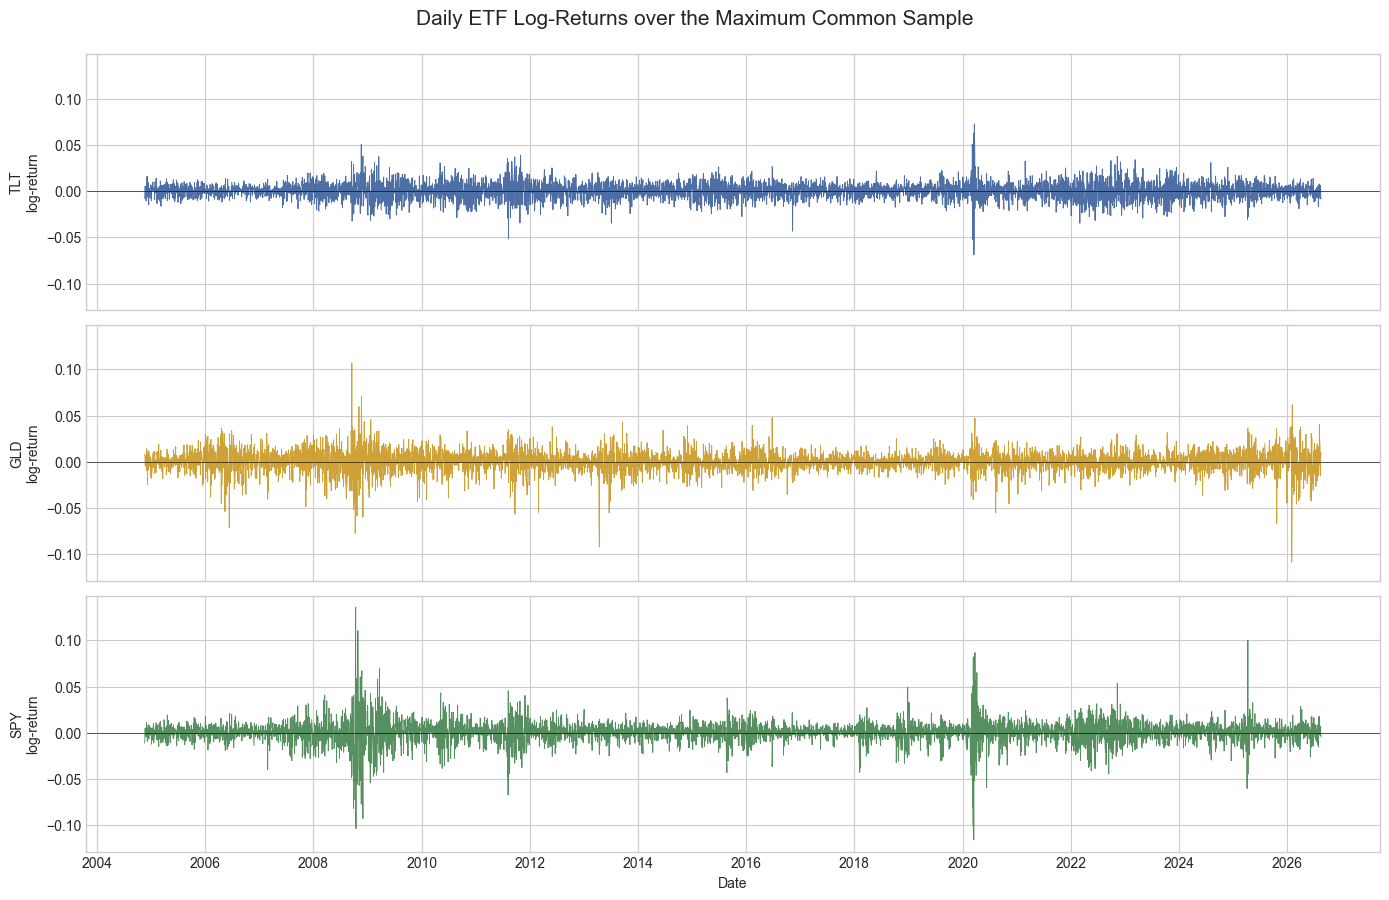

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)

for ax, ticker in zip(axes, ETF_TICKERS):
    column = f"{ticker}_Log_Return"
    ax.plot(
        clean_data.index,
        clean_data[column],
        color=COLORS[ticker],
        linewidth=0.65,
        alpha=0.85,
    )
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
    ax.set_ylabel(f"{ticker}\nlog-return")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Daily ETF Log-Returns over the Maximum Common Sample", fontsize=15, y=0.995)
fig.tight_layout()
plt.show()

**Interpretation.** All three ETF return series fluctuate around zero, which is expected for daily returns. Large movements appear in clusters, especially around market stress periods. SPY and GLD show larger maximum one-day movements than TLT in this sample, while TLT still experiences visible volatility episodes. The shared time axis confirms that the three return series are aligned before the regime analysis.

## 1.5 Plot the daily change in VIX

The plot showing $\Delta VIX$ (or VIX returns) follows below.

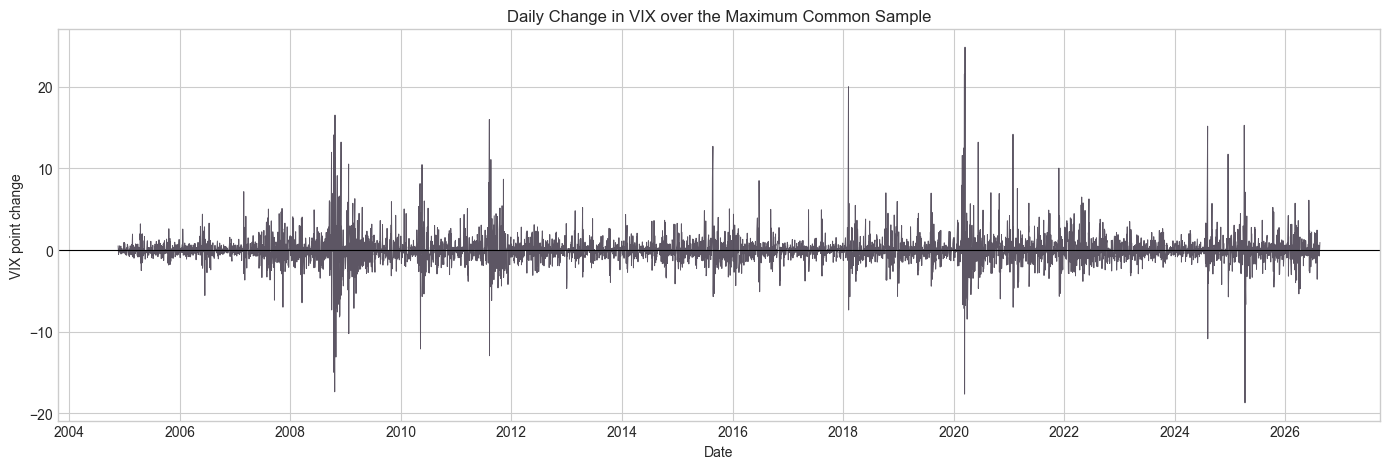

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(
    clean_data.index,
    clean_data["VIX_Change"],
    color=COLORS["VIX"],
    linewidth=0.7,
    alpha=0.9,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Daily Change in VIX over the Maximum Common Sample")
ax.set_xlabel("Date")
ax.set_ylabel("VIX point change")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

**Interpretation.** Daily VIX changes are centered close to zero but contain occasional extreme spikes. Positive spikes are especially important because they represent sudden increases in expected market volatility. The uneven, clustered pattern supports the idea that a single constant-volatility description is too simple and motivates a regime-based model.

**Step 1 conclusion.** The four price series have been aligned on their maximum common dates, all missing values have been removed from the model-ready table, and the transformations and plots are consistent with the assignment. The raw and clean data are saved as separate CSV files beside the notebook.

# Step 2 - Modeling VIX Regimes with a Discrete Markov Chain

## 2.1 Define three states using quantiles

The 33.33rd and 66.67th percentiles divide the observations into three groups of nearly equal size without imposing arbitrary fixed cutoffs:

- **Low change:** the lowest third of daily VIX changes, typically a meaningful fall in VIX.
- **Medium change:** the middle third, usually a small move near zero.
- **High change:** the highest third, typically a meaningful rise in VIX.

These labels describe the daily *change* in VIX, not the absolute VIX level. This distinction is important: a high VIX level can still fall on a given day and therefore receive the “Low change” label.

In [8]:
STATE_ORDER = ["Low change", "Medium change", "High change"]

lower_cutoff, upper_cutoff = clean_data["VIX_Change"].quantile([1 / 3, 2 / 3])

regime_data = clean_data.copy()
regime_data["VIX_State"] = pd.qcut(
    regime_data["VIX_Change"],
    q=3,
    labels=STATE_ORDER,
)

state_summary = (
    regime_data.groupby("VIX_State", observed=True)
    .agg(
        Observations=("VIX_Change", "size"),
        Mean_VIX_Change=("VIX_Change", "mean"),
        Std_VIX_Change=("VIX_Change", "std"),
        Mean_VIX_Level=("VIX_Adj_Close", "mean"),
    )
    .reindex(STATE_ORDER)
)
state_summary["Sample_Share"] = state_summary["Observations"] / len(regime_data)

print(f"33.33rd percentile cutoff: {lower_cutoff:.4f} VIX points")
print(f"66.67th percentile cutoff: {upper_cutoff:.4f} VIX points")
display(state_summary)

33.33rd percentile cutoff: -0.4700 VIX points
66.67th percentile cutoff: 0.3000 VIX points


,Observations,Mean_VIX_Change,Std_VIX_Change,Mean_VIX_Level,Sample_Share
VIX_State,,,,,
Low change,1824,-1.510795,1.449388,20.454145,0.333577
Medium change,1824,-0.091212,0.210031,15.913470,0.333577
High change,1820,1.606742,1.958662,20.936489,0.332846


**Interpretation.** The low-change state has a negative mean $\Delta VIX$, the medium state is close to zero, and the high-change state has a positive mean. The state counts are almost equal by construction because quantile cutoffs are used. The average VIX level is higher in the low- and high-change states than in the medium state, showing that large daily movements in either direction tend to occur when overall volatility is elevated.

## 2.2 Estimate the transition matrix

A transition probability answers a simple question: “Given today's VIX-change state, what is the probability of each state on the next trading day?” The row is today's state, the column is tomorrow's state, and each row must sum to one.

For states $i$ and $j$,

$$\hat{P}_{ij}=\frac{\text{number of observed transitions from }i\text{ to }j}{\text{number of observed transitions out of }i}.$$

In [9]:
current_state = regime_data["VIX_State"].iloc[:-1].astype(str)
next_state = regime_data["VIX_State"].iloc[1:].astype(str)

transition_counts = pd.crosstab(
    current_state.to_numpy(),
    next_state.to_numpy(),
).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)

transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
transition_matrix.index.name = "Current state"
transition_matrix.columns.name = "Next state"

print("Observed transition counts")
display(transition_counts)
print("Estimated transition matrix")
display(transition_matrix)
print("Row-sum check")
display(transition_matrix.sum(axis=1).rename("Row sum").to_frame())

Observed transition counts


Next state,Low change,Medium change,High change
Current state,,,
Low change,637,556,631
Medium change,427,783,614
High change,760,485,574


Estimated transition matrix


Next state,Low change,Medium change,High change
Current state,,,
Low change,0.349232,0.304825,0.345943
Medium change,0.234101,0.429276,0.336623
High change,0.417812,0.266630,0.315558


Row-sum check


,Row sum
Current state,
Low change,1.000000
Medium change,1.000000
High change,1.000000


A diagonal entry is the probability that the same state continues on the next day. An off-diagonal entry is the probability of moving to a different state. In this sample, the medium-change state is the most persistent. After a high-change day, a move to the low-change state is more common than another high-change day, which is consistent with short-run mean reversion in daily VIX changes.

## 2.3 Calculate the stationary distribution


 The stationary distribution is the long-run fraction of time implied by the estimated transition matrix. It is a probability vector $\pi$ satisfying

$$\pi = \pi P, \qquad \sum_i \pi_i = 1.$$

It describes the model's long-run state balance if the estimated transition behavior remains stable. It is not a forecast that tomorrow must have these probabilities.

In [10]:
eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.to_numpy().T)
stationary_index = np.argmin(np.abs(eigenvalues - 1))
stationary_values = np.real(eigenvectors[:, stationary_index])

# Eigenvectors can be returned with either sign; normalize to non-negative probabilities.
if stationary_values.sum() < 0:
    stationary_values = -stationary_values
stationary_values = stationary_values / stationary_values.sum()

stationary_distribution = pd.Series(
    stationary_values,
    index=STATE_ORDER,
    name="Stationary probability",
)
observed_distribution = (
    regime_data["VIX_State"].value_counts(normalize=True).reindex(STATE_ORDER)
)

distribution_comparison = pd.concat(
    [
        stationary_distribution,
        observed_distribution.rename("Observed sample share"),
    ],
    axis=1,
)

display(distribution_comparison)
print(f"Stationary probabilities sum to {stationary_distribution.sum():.6f}.")

,Stationary probability,Observed sample share
Low change,0.333638,0.333577
Medium change,0.333638,0.333577
High change,0.332724,0.332846


Stationary probabilities sum to 1.000000.


**Interpretation.** The stationary probabilities are close to one-third for each state. This is expected because the states were created from sample terciles, although the stationary distribution is determined by the sequence of transitions rather than by the state counts alone. The close match between the stationary probabilities and observed sample shares is a useful consistency check.

## 2.4 Plot VIX with color-coded states

The gray line shows the VIX level. Each colored point shows the state assigned from that day's VIX change. This connects the transition model's categories to the familiar VIX time series.

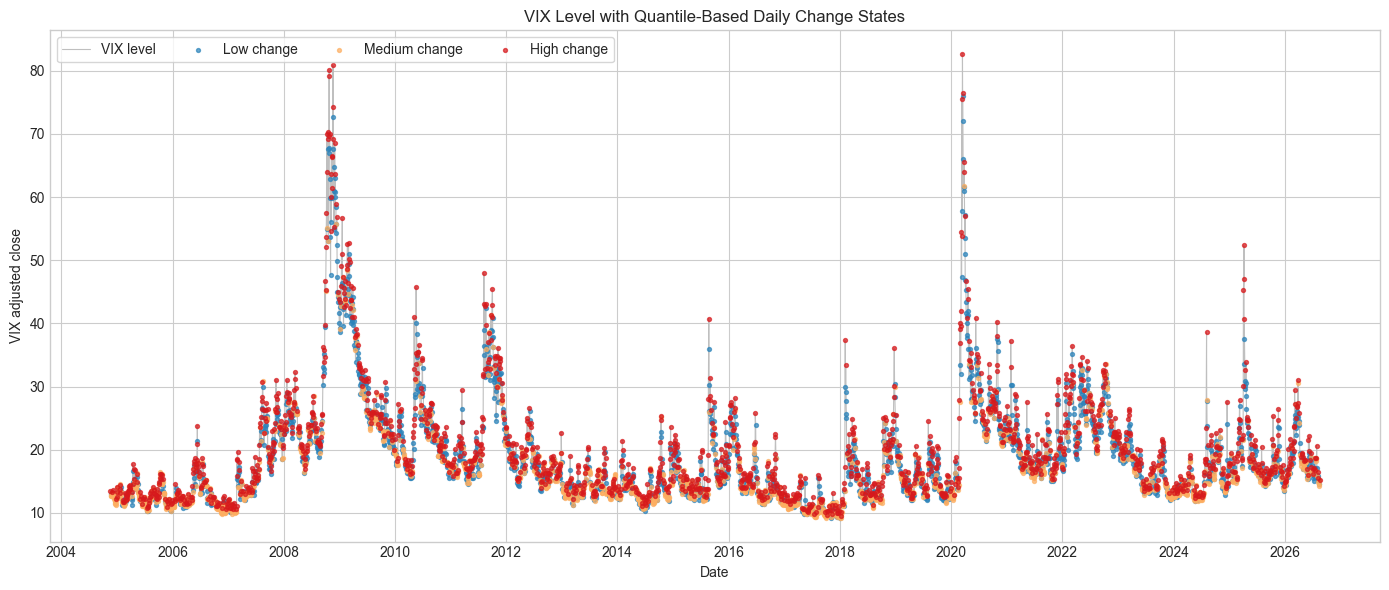

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    regime_data.index,
    regime_data["VIX_Adj_Close"],
    color="0.75",
    linewidth=0.8,
    label="VIX level",
    zorder=1,
)

for state in STATE_ORDER:
    mask = regime_data["VIX_State"] == state
    ax.scatter(
        regime_data.index[mask],
        regime_data.loc[mask, "VIX_Adj_Close"],
        s=8,
        alpha=0.70,
        color=COLORS[state],
        label=state,
        zorder=2,
    )

ax.set_title("VIX Level with Quantile-Based Daily Change States")
ax.set_xlabel("Date")
ax.set_ylabel("VIX adjusted close")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(ncol=4, frameon=True, loc="upper left")
fig.tight_layout()
plt.show()

**Interpretation.** The colors frequently alternate because the model classifies one-day VIX changes rather than persistent VIX levels. High-change observations cluster around abrupt upward moves, while low-change observations often follow volatility spikes as VIX falls back. The model is transparent and meets the Step 2 requirement, but the state labels should not be interpreted as low, medium, and high *levels* of VIX.

## Step 2 conclusion

The three-state discrete Markov chain provides all required Step 2 deliverables: explicit quantile state definitions, transition counts, a row-normalized transition matrix, a stationary distribution, and a VIX chart with color-coded states. The results suggest that small VIX changes are more persistent than large changes and that high-change days are often followed by low-change days.

No model comparison, asset-by-state analysis, allocation rule, or backtest is included because those belong to Steps 3-5 and are outside the requested scope.

## References (MLA style)

WorldQuant University. *MScFE 622 Stochastic Modeling: Group Work Project 2*. Oct. 2025.

Yahoo Finance. “Historical Data.” *Yahoo Finance*, accessed 18 Aug. 2026. [TLT](https://finance.yahoo.com/quote/TLT/history/), [GLD](https://finance.yahoo.com/quote/GLD/history/), [SPY](https://finance.yahoo.com/quote/SPY/history/), and [CBOE Volatility Index](https://finance.yahoo.com/quote/%5EVIX/history/). Data retrieved through the `yfinance` interface and preserved in `yfinance_adjusted_close_raw.csv`.

Aroussi, Ran. “Ticker.history.” *yfinance Documentation*, [ranaroussi.github.io/yfinance](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.history.html). Accessed 18 Aug. 2026.

Norris, J. R. *Markov Chains*. Cambridge University Press, 1998.